<a href="https://colab.research.google.com/github/DeepthiManthapuram/Celebal_Excellence_Internship/blob/main/week3_Deepthi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install required libraries

In [19]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

# Import libraries

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data


In [8]:
import os
os.listdir(path)

['Country-data.csv', 'data-dictionary.csv']

In [22]:
import os
import pandas as pd
df = pd.read_csv(os.path.join(path, 'Country-data.csv'))


# Data Cleaning

In [14]:
#checking data
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [24]:
#Checking column names
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [25]:
#Removing extra spaces if present
df.columns = df.columns.str.strip()

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
 10  Cluster     167 non-null    int32  
dtypes: float64(7), int32(1), int64(2), object(1)
memory usage: 13.8+ KB


In [16]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [17]:
#checking missing values
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [18]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

In [26]:
#Checking data types
df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [28]:
#Separate Country Column
#The country column should not be used for clustering.
countries = df["country"]

X = df.drop("country", axis=1)

# Standard Scaling

In [29]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method

In [30]:
inertia = []

k_values = range(2,11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Curve

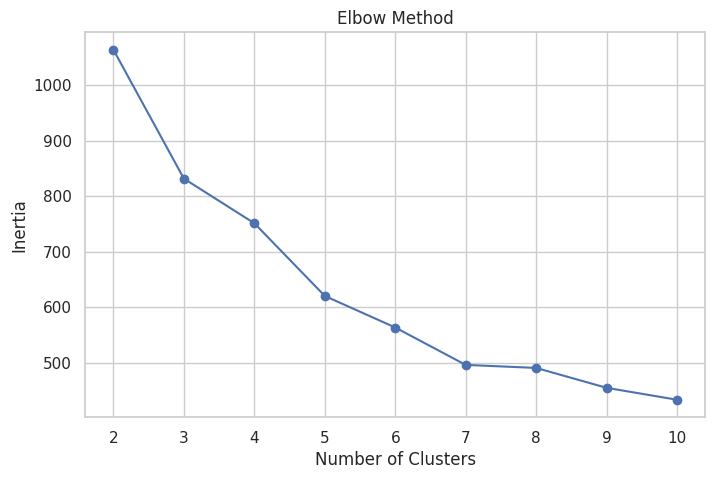

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# Train Final K-Means (k=3)

In [32]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Silhouette Score

In [33]:
score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.285600988953231


# DBSCAN

In [34]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

print(
    np.unique(dbscan_labels)
)

[-1  0]


# PCA to 2D

In [35]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

# K-Means Scatter Plot

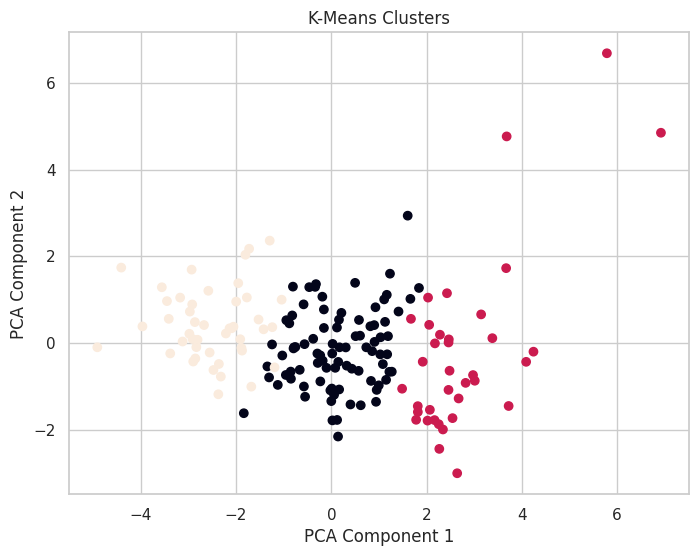

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.title("K-Means Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

# Cluster Summary

Add cluster labels.

In [37]:
df["Cluster"] = kmeans_labels

In [38]:
#Compute averages
cluster_summary = df.groupby(
    "Cluster"
).mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


# Observations

1) The Elbow Method shows a noticeable bend around k = 3, indicating that dividing the countries into three clusters provides a good balance between model simplicity and cluster separation.

2) Cluster 1 represents highly developed countries, with the highest average income (45,672), GDP per capita (42,494), and life expectancy (80.13 years), along with the lowest child mortality (5.0). These countries can be considered top-tier economic zones.

3) Cluster 2 represents low-development regions, characterized by very high child mortality (95.11), low income (3,540), low GDP per capita (1,767), and low life expectancy (59.06 years). These countries may require significant economic and healthcare support.

4) Cluster 0 represents developing economies, with moderate income (12,322), GDP per capita (6,462), and life expectancy (72.57 years). This cluster lies between the developed and underdeveloped groups and may have strong growth potential.

5) The PCA visualization shows that the three K-Means clusters are reasonably separated in two-dimensional space. The silhouette score of 0.286 indicates moderate cluster quality, suggesting that countries within the same cluster share similar socio-economic characteristics.

6) DBSCAN identified only one dense cluster and labeled some countries as outliers (-1). This suggests that the dataset contains a few countries with socio-economic characteristics that differ significantly from the majority.